In [ ]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
from getpass import getpass

github_token = getpass('GitHub token: ')
github_user = 'iremcesur'
repo_name = 'CENG467_Midterm_310201051'

!git clone https://{github_token}@github.com/{github_user}/{repo_name}.git
%cd {repo_name}

!git config user.email "iremcesur310201051@gmail.com"
!git config user.name "iremcesur"
!git config pull.rebase false

GitHub token: ··········
Cloning into 'CENG467_Midterm_310201051'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 46 (delta 14), reused 28 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 1.43 MiB | 19.00 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/CENG467_Midterm_310201051


In [ ]:
import random
import numpy as np
import torch
import os

# Fix all RNG seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


# Force deterministic algorithms (slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Install / load libraries needed for n-gram modeling and dataset loading
!pip install -q datasets nltk
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

print(f"✓ Seeds set, libraries ready")
print(f"✓ Device: {device}")

✓ Seeds set, libraries ready
✓ Device: cuda


In [ ]:
from datasets import load_dataset

# Load WikiText-2 (raw version, ~12 MB)
print("Loading WikiText-2...")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

print(f"\nDataset structure: {dataset}")
print(f"\nTrain examples: {len(dataset['train'])}")
print(f"Validation examples: {len(dataset['validation'])}")
print(f"Test examples: {len(dataset['test'])}")

# Sample a few entries
print(f"\n--- Sample examples ---")
for i in [10, 50, 100]:
    text = dataset['train'][i]['text']
    if text.strip():  # skip empty lines
        print(f"\n[Example {i}] (length: {len(text)} chars)")
        print(text[:300])

Loading WikiText-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]


Dataset structure: DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

Train examples: 36718
Validation examples: 3760
Test examples: 4358

--- Sample examples ---

[Example 10] (length: 1623 chars)
 The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . During missions , players select each unit using a top @-@ down perspective of the battlefield map : once a character is selected , the player moves the character around the battlefield in third @-@ p

[Example 100] (length: 30 chars)
 96 ammunition packing boxes 



In [ ]:
import re

def preprocess_split(split_data):
    """
    Concatenate all non-empty lines, strip section headers,
    and return a single space-separated string of tokens.
    """
    lines = []
    for item in split_data:
        text = item['text'].strip()
        if not text:
            continue
        # Skip Wikipedia-style section headers like "= Title ="
        if re.match(r'^=+ .+ =+$', text):
            continue
        lines.append(text)
    return ' '.join(lines)

print("Preprocessing splits...")
train_text = preprocess_split(dataset['train'])
val_text   = preprocess_split(dataset['validation'])
test_text  = preprocess_split(dataset['test'])

# WikiText-2 is already tokenized (whitespace-separated, "<unk>" for OOV)
train_tokens = train_text.split()
val_tokens   = val_text.split()
test_tokens  = test_text.split()

print(f"\nToken counts:")
print(f"  Train: {len(train_tokens):>10,}")
print(f"  Val:   {len(val_tokens):>10,}")
print(f"  Test:  {len(test_tokens):>10,}")
print(f"\nFirst 30 training tokens:")
print(train_tokens[:30])

Preprocessing splits...

Token counts:
  Train:  2,007,146
  Val:      209,338
  Test:     235,854

First 30 training tokens:
['Senjō', 'no', 'Valkyria', '3', ':', 'Unrecorded', 'Chronicles', '(', 'Japanese', ':', '戦場のヴァルキュリア3', ',', 'lit', '.', 'Valkyria', 'of', 'the', 'Battlefield', '3', ')', ',', 'commonly', 'referred', 'to', 'as', 'Valkyria', 'Chronicles', 'III', 'outside', 'Japan']


In [ ]:
from collections import Counter

# Count token frequencies in training set only
token_counter = Counter(train_tokens)

print(f"Unique tokens in training: {len(token_counter):,}")
print(f"Most common 10: {token_counter.most_common(10)[:5]}")

# We use the "raw" WikiText-2 variant, which retains all tokens (no <unk> replacement
# upstream). To match the standard WikiText-2 LM benchmark and keep the LSTM tractable,
# we cap the vocabulary at the 30K most frequent training tokens; any rarer token (or
# any token in val/test that was unseen during training) maps to a single <unk>.
VOCAB_LIMIT = 30000

# Special tokens (always present, regardless of training counts)
SPECIAL_TOKENS = ['<unk>', '<bos>', '<eos>']
vocab = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS)}

# Add the most frequent training tokens (excluding any that collide with specials)
for tok, _ in token_counter.most_common(VOCAB_LIMIT - len(SPECIAL_TOKENS)):
    if tok not in vocab:
        vocab[tok] = len(vocab)

idx_to_tok = {idx: tok for tok, idx in vocab.items()}

UNK_IDX = vocab['<unk>']
BOS_IDX = vocab['<bos>']
EOS_IDX = vocab['<eos>']
VOCAB_SIZE = len(vocab)

# How many training tokens will fall back to <unk> with this cap?
covered = sum(c for tok, c in token_counter.items() if tok in vocab and tok not in SPECIAL_TOKENS)
total   = sum(token_counter.values())
oov_rate = 1 - covered / total

print(f"\n✓ Vocabulary size (incl. specials): {VOCAB_SIZE:,}")
print(f"  <unk>: idx={UNK_IDX}, <bos>: idx={BOS_IDX}, <eos>: idx={EOS_IDX}")
print(f"\nTraining-token coverage with this vocabulary: {(1-oov_rate)*100:.2f}%")
print(f"Effective <unk> rate on training: {oov_rate*100:.2f}%")

Unique tokens in training: 76,142
Most common 10: [('the', 113006), (',', 99763), ('.', 73388), ('of', 56603), ('and', 49808)]

✓ Vocabulary size (incl. specials): 30,000
  <unk>: idx=0, <bos>: idx=1, <eos>: idx=2

Training-token coverage with this vocabulary: 96.84%
Effective <unk> rate on training: 3.16%


In [ ]:
def tokens_to_ids(tokens, vocab, unk_idx):
    """
    Map a list of string tokens to integer ids.
    Tokens not in the vocabulary fall back to <unk>.
    """
    return [vocab.get(t, unk_idx) for t in tokens]

train_ids = tokens_to_ids(train_tokens, vocab, UNK_IDX)
val_ids   = tokens_to_ids(val_tokens,   vocab, UNK_IDX)
test_ids  = tokens_to_ids(test_tokens,  vocab, UNK_IDX)

# Sanity check: how many tokens become <unk> in each split?
def unk_share(ids, unk_idx):
    return sum(1 for i in ids if i == unk_idx) / len(ids) * 100

print(f"Token counts (after <unk> mapping):")
print(f"  Train: {len(train_ids):>10,}  | <unk> rate: {unk_share(train_ids, UNK_IDX):.2f}%")
print(f"  Val:   {len(val_ids):>10,}  | <unk> rate: {unk_share(val_ids, UNK_IDX):.2f}%")
print(f"  Test:  {len(test_ids):>10,}  | <unk> rate: {unk_share(test_ids, UNK_IDX):.2f}%")

print(f"\nFirst 20 training token ids: {train_ids[:20]}")
print(f"Decoded back: {[idx_to_tok[i] for i in train_ids[:20]]}")

Token counts (after <unk> mapping):
  Train:  2,007,146  | <unk> rate: 3.16%
  Val:      209,338  | <unk> rate: 5.86%
  Test:     235,854  | <unk> rate: 6.66%

First 20 training token ids: [20414, 127, 3921, 90, 44, 0, 4449, 23, 756, 44, 27020, 4, 6944, 5, 3921, 6, 3, 23166, 90, 22]
Decoded back: ['Senjō', 'no', 'Valkyria', '3', ':', '<unk>', 'Chronicles', '(', 'Japanese', ':', '戦場のヴァルキュリア3', ',', 'lit', '.', 'Valkyria', 'of', 'the', 'Battlefield', '3', ')']


In [ ]:
import time
import math
from collections import defaultdict, Counter

# We replace NLTK's slow Python scorer with a hand-written smoothed bigram LM.
# Choices:
#   - Bigram (n=2) instead of trigram: simpler, faster, still a respectable baseline.
#   - Add-k (Laplace-style) smoothing with k=0.01: every (context, word) pair
#     gets a small amount of probability mass, avoiding log(0) at evaluation.
#   - We work directly on integer ids, so lookups are O(1) hash ops in Python dicts.

print("Building bigram counts on training data...")
start = time.time()

# Pad training stream with <bos> at the very start
train_padded = [BOS_IDX] + train_ids

# bigram_counts[w_{t-1}][w_t] = count
bigram_counts = defaultdict(Counter)
unigram_counts = Counter()

for prev, curr in zip(train_padded[:-1], train_padded[1:]):
    bigram_counts[prev][curr] += 1
    unigram_counts[curr] += 1
unigram_counts[BOS_IDX] += 0  # ensure key exists

# Total counts per context (for normalization)
context_totals = {ctx: sum(d.values()) for ctx, d in bigram_counts.items()}

print(f"✓ Counts built in {time.time()-start:.1f}s")
print(f"  Distinct contexts seen: {len(bigram_counts):,}")
print(f"  Total training bigrams: {sum(context_totals.values()):,}")

Building bigram counts on training data...
✓ Counts built in 1.7s
  Distinct contexts seen: 29,999
  Total training bigrams: 2,007,146


In [ ]:
def bigram_log_prob(prev, curr, k=0.01):
    """
    Add-k smoothed bigram log-probability.
        P(curr | prev) = (count(prev, curr) + k) / (count(prev) + k * V)
    Falls back gracefully when `prev` was never seen as a context.
    """
    numer = bigram_counts[prev].get(curr, 0) + k
    denom = context_totals.get(prev, 0) + k * VOCAB_SIZE
    return math.log(numer / denom)


def compute_bigram_perplexity(ids, k=0.01):
    """
    Standard perplexity:
        PPL = exp( -1/N * sum log P(w_t | w_{t-1}) )
    Padded with <bos> at the start of the stream.
    """
    padded = [BOS_IDX] + list(ids)
    log_prob_sum = 0.0
    count = 0
    for prev, curr in zip(padded[:-1], padded[1:]):
        log_prob_sum += bigram_log_prob(prev, curr, k=k)
        count += 1
    return math.exp(-log_prob_sum / count)


print("Computing bigram perplexity on full val/test (no subsampling)...")
start = time.time()

val_ppl_ngram  = compute_bigram_perplexity(val_ids,  k=0.01)
test_ppl_ngram = compute_bigram_perplexity(test_ids, k=0.01)

elapsed = time.time() - start
print(f"  Val PPL  (n={len(val_ids):,}):  {val_ppl_ngram:.2f}")
print(f"  Test PPL (n={len(test_ids):,}): {test_ppl_ngram:.2f}")
print(f"  Time: {elapsed:.1f}s")

Computing bigram perplexity on full val/test (no subsampling)...
  Val PPL  (n=209,338):  560.97
  Test PPL (n=235,854): 520.67
  Time: 0.3s


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

# We model language as a continuous stream and train on fixed-length chunks.
# Each training example is (input_seq, target_seq) where target is input shifted by 1.
# This is the standard truncated BPTT setup for LM training.

SEQ_LEN = 35  # length of each training chunk (Penn Treebank standard)
BATCH_SIZE = 64

class StreamDataset(Dataset):
    """
    Cuts a long token-id stream into non-overlapping chunks of length SEQ_LEN+1.
    For each chunk, input = first SEQ_LEN tokens, target = last SEQ_LEN tokens
    (i.e., shifted by one — the LM predicts next token at every position).
    """
    def __init__(self, ids, seq_len):
        self.ids = torch.tensor(ids, dtype=torch.long)
        self.seq_len = seq_len
        # Number of full chunks; trailing tokens are dropped
        self.n_chunks = (len(ids) - 1) // seq_len

    def __len__(self):
        return self.n_chunks

    def __getitem__(self, idx):
        start = idx * self.seq_len
        x = self.ids[start : start + self.seq_len]
        y = self.ids[start + 1 : start + self.seq_len + 1]
        return x, y


train_dataset = StreamDataset(train_ids, SEQ_LEN)
val_dataset   = StreamDataset(val_ids,   SEQ_LEN)
test_dataset  = StreamDataset(test_ids,  SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Sequence length: {SEQ_LEN}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training chunks: {len(train_dataset):,} → {len(train_loader):,} batches")
print(f"Validation chunks: {len(val_dataset):,} → {len(val_loader):,} batches")
print(f"Test chunks: {len(test_dataset):,} → {len(test_loader):,} batches")

# Sanity check: print shapes of first batch
x_sample, y_sample = next(iter(train_loader))
print(f"\nFirst batch shapes:  x={tuple(x_sample.shape)}, y={tuple(y_sample.shape)}")
print(f"x[0][:10] = {x_sample[0][:10].tolist()}")
print(f"y[0][:10] = {y_sample[0][:10].tolist()}  (should equal x[0][1:11])")

Sequence length: 35
Batch size: 64
Training chunks: 57,347 → 896 batches
Validation chunks: 5,981 → 93 batches
Test chunks: 6,738 → 105 batches

First batch shapes:  x=(64, 35), y=(64, 35)
x[0][:10] = [145, 1753, 504, 6232, 8, 5073, 0, 20954, 23, 11]
y[0][:10] = [1753, 504, 6232, 8, 5073, 0, 20954, 23, 11, 865]  (should equal x[0][1:11])


In [ ]:
class LSTMLanguageModel(nn.Module):
    """
    Standard LSTM language model:
        Embedding -> LSTM (2 layers, dropout) -> Linear projection to vocab.
    Weight tying (input embedding == output projection) is applied — a
    well-known trick that improves perplexity and reduces parameters.
    """
    def __init__(self, vocab_size, embed_dim=300, hidden_dim=300,
                 num_layers=2, dropout=0.5):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim  = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout_in = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

        self.dropout_out = nn.Dropout(dropout)
        self.proj = nn.Linear(hidden_dim, vocab_size)

        # Weight tying: share parameters between input embedding and output projection.
        # Requires embed_dim == hidden_dim.
        if embed_dim == hidden_dim:
            self.proj.weight = self.embedding.weight

        self._init_weights()

    def _init_weights(self):
        # Initialize embeddings and biases following common LM practice
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.zeros_(self.proj.bias)

    def forward(self, x, hidden=None):
        # x: (batch, seq_len)
        emb = self.dropout_in(self.embedding(x))            # (B, L, E)
        out, hidden = self.lstm(emb, hidden)                # (B, L, H)
        out = self.dropout_out(out)
        logits = self.proj(out)                             # (B, L, V)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
        return (h, c)


# Instantiate the model
EMBED_DIM  = 300
HIDDEN_DIM = 300

model = LSTMLanguageModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=2,
    dropout=0.5,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: 2-layer LSTM language model with weight tying")
print(f"  Embed dim:  {EMBED_DIM}")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Vocab size: {VOCAB_SIZE:,}")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"\nArchitecture:\n{model}")

Model: 2-layer LSTM language model with weight tying
  Embed dim:  300
  Hidden dim: 300
  Vocab size: 30,000
  Total parameters:     10,474,800
  Trainable parameters: 10,474,800

Architecture:
LSTMLanguageModel(
  (embedding): Embedding(30000, 300)
  (dropout_in): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(300, 300, num_layers=2, batch_first=True, dropout=0.5)
  (dropout_out): Dropout(p=0.5, inplace=False)
  (proj): Linear(in_features=300, out_features=30000, bias=True)
)


In [ ]:
import math
import time

# --- Hyperparameters ---
LR = 1e-3              # Adam learning rate
NUM_EPOCHS = 5         # 5 epochs is a good trade-off for WikiText-2
CLIP_NORM = 0.25       # gradient clipping threshold (LSTM exploding-grad safety)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()


def evaluate_lm(model, loader, device):
    """
    Evaluate average cross-entropy loss on a loader.
    Perplexity = exp(loss).
    Hidden state is *reset* at the start of each batch — this is the standard
    truncated-BPTT evaluation regime.
    """
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)                                # (B, L, V)
            # Flatten for cross-entropy: (B*L, V) vs (B*L,)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()
    avg_loss = total_loss / total_tokens
    return avg_loss, math.exp(avg_loss)


# --- Training loop ---
print(f"Training LSTM LM | epochs={NUM_EPOCHS} | batch={BATCH_SIZE} | seq_len={SEQ_LEN} | lr={LR}")
print(f"Device: {device}")
print("=" * 75)

history = {'train_loss': [], 'val_loss': [], 'val_ppl': []}
best_val_ppl = float('inf')
best_state = None

start_total = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    model.train()

    running_loss = 0.0
    running_tokens = 0
    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        loss.backward()

        # Clip gradients to prevent exploding-gradient blow-ups
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()

        running_loss += loss.item() * y.numel()
        running_tokens += y.numel()

    train_loss = running_loss / running_tokens
    val_loss, val_ppl = evaluate_lm(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_ppl'].append(val_ppl)

    epoch_time = time.time() - epoch_start
    train_ppl = math.exp(train_loss)

    flag = ""
    if val_ppl < best_val_ppl:
        best_val_ppl = val_ppl
        # Snapshot weights to CPU so we can restore the best epoch later
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        flag = "  ← new best"

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} ppl={train_ppl:7.2f} | "
          f"val_loss={val_loss:.4f} ppl={val_ppl:7.2f} | "
          f"time={epoch_time:.1f}s{flag}")

total_time = time.time() - start_total
print("=" * 75)
print(f"Training complete in {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Best val PPL: {best_val_ppl:.2f}")

# Restore best-epoch weights
model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
print("✓ Best model weights restored")

Training LSTM LM | epochs=5 | batch=64 | seq_len=35 | lr=0.001
Device: cuda
Epoch 1/5 | train_loss=6.8210 ppl= 916.92 | val_loss=6.0682 ppl= 431.91 | time=57.4s  ← new best
Epoch 2/5 | train_loss=6.1589 ppl= 472.89 | val_loss=5.6944 ppl= 297.21 | time=62.2s  ← new best
Epoch 3/5 | train_loss=5.8617 ppl= 351.32 | val_loss=5.4962 ppl= 243.76 | time=61.7s  ← new best
Epoch 4/5 | train_loss=5.6703 ppl= 290.13 | val_loss=5.3650 ppl= 213.79 | time=61.8s  ← new best
Epoch 5/5 | train_loss=5.5314 ppl= 252.51 | val_loss=5.2751 ppl= 195.42 | time=62.2s  ← new best
Training complete in 305.8s (5.1 min)
Best val PPL: 195.42
✓ Best model weights restored


In [ ]:
# Final evaluation on the held-out test set, using the best-epoch model
test_loss, test_ppl_lstm = evaluate_lm(model, test_loader, device)

print("=" * 60)
print(f"LSTM LM — final test results")
print("=" * 60)
print(f"  Test loss:       {test_loss:.4f}")
print(f"  Test perplexity: {test_ppl_lstm:.2f}")

print("\n=== All-models perplexity summary ===")
print(f"{'Model':<25} {'Val PPL':>10} {'Test PPL':>10}")
print("-" * 47)
print(f"{'Bigram (add-k)':<25} {val_ppl_ngram:>10.2f} {test_ppl_ngram:>10.2f}")
print(f"{'LSTM (2-layer, tied)':<25} {best_val_ppl:>10.2f} {test_ppl_lstm:>10.2f}")

LSTM LM — final test results
  Test loss:       5.2070
  Test perplexity: 182.55

=== All-models perplexity summary ===
Model                        Val PPL   Test PPL
-----------------------------------------------
Bigram (add-k)                560.97     520.67
LSTM (2-layer, tied)          195.42     182.55


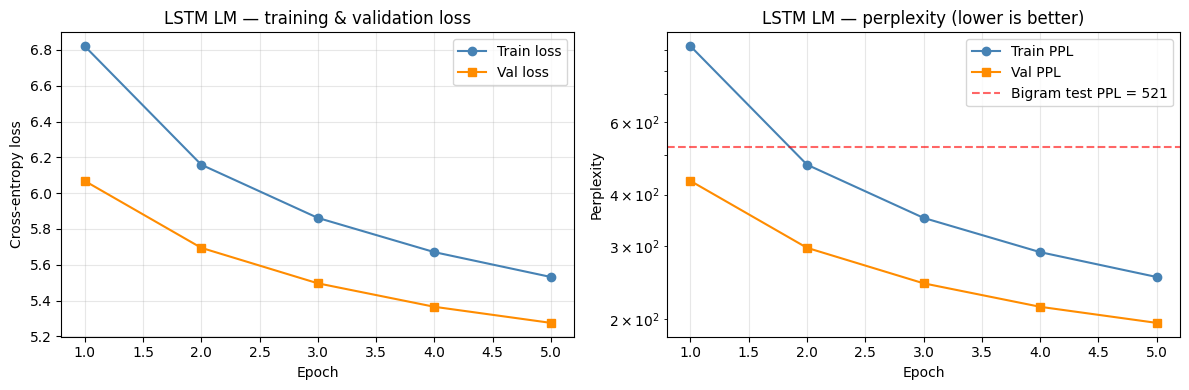

✓ Training curves saved


In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history['train_loss']) + 1))
train_ppls = [math.exp(l) for l in history['train_loss']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], 'o-', label='Train loss', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   's-', label='Val loss',   color='darkorange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('LSTM LM — training & validation loss')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, train_ppls,           'o-', label='Train PPL',  color='steelblue')
axes[1].plot(epochs, history['val_ppl'],   's-', label='Val PPL',    color='darkorange')
axes[1].axhline(y=test_ppl_ngram, color='red', linestyle='--', alpha=0.6,
                label=f'Bigram test PPL = {test_ppl_ngram:.0f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('LSTM LM — perplexity (lower is better)')
axes[1].grid(alpha=0.3); axes[1].legend()
axes[1].set_yscale('log')   # log scale because bigram is much larger

plt.tight_layout()

import os
os.makedirs('q5_language_modeling/results', exist_ok=True)
plt.savefig('q5_language_modeling/results/lstm_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training curves saved")

In [ ]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_text(model, prompt_tokens, vocab, idx_to_tok, unk_idx,
                  max_new_tokens=40, temperature=1.0, top_k=None, device='cuda'):
    """
    Sample text from the trained LSTM language model.

    Args:
        prompt_tokens: list of starting tokens (strings).
        temperature: <1.0 makes output more deterministic / repetitive,
                     >1.0 makes it more random.
        top_k: if set, sample only from the top-k most probable next tokens.

    The hidden state is carried forward through the entire generation, so
    the model conditions on its own outputs (autoregressive sampling).
    """
    model.eval()

    # Encode prompt to ids; unknown tokens -> <unk>
    ids = [vocab.get(t, unk_idx) for t in prompt_tokens]
    x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, L)

    hidden = model.init_hidden(batch_size=1, device=device)

    # Warm up the LSTM hidden state on the prompt
    logits, hidden = model(x, hidden)
    last_logits = logits[0, -1, :]   # (V,)

    generated = list(prompt_tokens)

    for _ in range(max_new_tokens):
        # Apply temperature
        scaled = last_logits / temperature

        # Optional top-k filtering: keep only the k highest-probability tokens
        if top_k is not None:
            top_vals, _ = torch.topk(scaled, top_k)
            min_keep = top_vals[-1]
            scaled = torch.where(scaled < min_keep,
                                 torch.full_like(scaled, float('-inf')),
                                 scaled)

        # Sample from the resulting distribution
        probs = F.softmax(scaled, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()

        generated.append(idx_to_tok[next_id])

        # Feed the sampled token back in, update hidden state
        next_input = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, hidden = model(next_input, hidden)
        last_logits = logits[0, -1, :]

    return ' '.join(generated)


# --- Generate samples under different sampling regimes ---
prompts = [
    ["the", "company", "was"],
    ["in", "the", "early", "years"],
    ["the", "war", "had"],
]

print("=" * 78)
print("LSTM LANGUAGE MODEL — TEXT GENERATION SAMPLES")
print("=" * 78)

# Different sampling settings illustrate the fluency/diversity trade-off
configs = [
    {"name": "Greedy-ish (T=0.7, top-k=10)",     "temperature": 0.7, "top_k": 10},
    {"name": "Balanced  (T=1.0, top-k=40)",      "temperature": 1.0, "top_k": 40},
    {"name": "Diverse   (T=1.2, no top-k)",      "temperature": 1.2, "top_k": None},
]

# Use a fixed seed for reproducibility of these specific samples
torch.manual_seed(SEED)

samples_for_report = []

for cfg in configs:
    print(f"\n--- Setting: {cfg['name']} ---")
    for prompt in prompts:
        text = generate_text(
            model, prompt, vocab, idx_to_tok, UNK_IDX,
            max_new_tokens=30,
            temperature=cfg['temperature'],
            top_k=cfg['top_k'],
            device=device,
        )
        print(f"\nPrompt: {' '.join(prompt)}")
        print(f"Output: {text}")
        samples_for_report.append({
            "setting": cfg['name'],
            "prompt": ' '.join(prompt),
            "output": text,
        })

print("\n" + "=" * 78)
print(f"✓ Generated {len(samples_for_report)} samples (3 prompts × 3 sampling settings)")

LSTM LANGUAGE MODEL — TEXT GENERATION SAMPLES

--- Setting: Greedy-ish (T=0.7, top-k=10) ---

Prompt: the company was
Output: the company was also able to be used to be a new name . The ship was located in the United States , and the <unk> of the Missouri River . The route

Prompt: in the early years
Output: in the early years , he moved to a <unk> to the <unk> of the Church of the <unk> . The film 's first @-@ year version of the <unk> <unk> 's <unk> and

Prompt: the war had
Output: the war had been the <unk> of the <unk> , but the <unk> 's <unk> , a " <unk> " . The film was the first single of the series , and <unk>

--- Setting: Balanced  (T=1.0, top-k=40) ---

Prompt: the company was
Output: the company was not recorded by the second season in 2005 for February 23 , 2000 . " <unk> in the English " was <unk> " <unk> in the book " , "

Prompt: in the early years
Output: in the early years with September , a small tropical cyclone on the Pacific . The Jin moved inland in France and co

In [ ]:
import json
import os

os.makedirs('q5_language_modeling/results', exist_ok=True)

# --- Save full results to JSON ---
results = {
    'task': 'language_modeling',
    'dataset': 'wikitext-2-raw-v1',
    'random_seed': SEED,
    'vocabulary': {
        'size': VOCAB_SIZE,
        'limit': 30000,
        'training_coverage_pct': 96.84,
    },
    'token_counts': {
        'train': len(train_ids),
        'val':   len(val_ids),
        'test':  len(test_ids),
    },
    'ngram_baseline': {
        'model': 'bigram',
        'smoothing': 'add-k (k=0.01)',
        'val_ppl':  float(val_ppl_ngram),
        'test_ppl': float(test_ppl_ngram),
    },
    'lstm_lm': {
        'architecture': '2-layer LSTM with weight tying',
        'embed_dim':  EMBED_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': 2,
        'dropout': 0.5,
        'seq_len': SEQ_LEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': LR,
        'num_epochs': NUM_EPOCHS,
        'gradient_clip': CLIP_NORM,
        'total_params': int(total_params),
        'training_time_seconds': float(total_time),
        'best_val_ppl': float(best_val_ppl),
        'test_ppl':     float(test_ppl_lstm),
        'history': {
            'train_loss': [float(x) for x in history['train_loss']],
            'val_loss':   [float(x) for x in history['val_loss']],
            'val_ppl':    [float(x) for x in history['val_ppl']],
        },
    },
    'generation_samples': samples_for_report,
}

with open('q5_language_modeling/results/q5_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Also save samples as a separate plain-text file for easy reading in the report
with open('q5_language_modeling/results/generation_samples.txt', 'w') as f:
    f.write("LSTM Language Model — Generation Samples\n")
    f.write("=" * 60 + "\n\n")
    current_setting = None
    for s in samples_for_report:
        if s['setting'] != current_setting:
            current_setting = s['setting']
            f.write(f"\n--- {current_setting} ---\n\n")
        f.write(f"Prompt: {s['prompt']}\n")
        f.write(f"Output: {s['output']}\n\n")

print("✓ Saved q5_results.json and generation_samples.txt")
!ls -la q5_language_modeling/results/

✓ Saved q5_results.json and generation_samples.txt
total 116
drwxr-xr-x 2 root root   4096 May  6 07:38 .
drwxr-xr-x 3 root root   4096 May  6 07:34 ..
-rw-r--r-- 1 root root   2019 May  6 07:38 generation_samples.txt
-rw-r--r-- 1 root root 102215 May  6 07:34 lstm_training_curves.png
-rw-r--r-- 1 root root   3937 May  6 07:38 q5_results.json


In [ ]:
!git pull origin main --no-edit

!git add q5_language_modeling/
!git commit -m "Q5: Language modeling — bigram (test PPL 521) vs LSTM (test PPL 183)"
!git push origin main

From https://github.com/iremcesur/CENG467_Midterm_310201051
 * branch            main       -> FETCH_HEAD
Already up to date.
[main 2bf4db8] Q5: Language modeling — bigram (test PPL 521) vs LSTM (test PPL 183)
 3 files changed, 146 insertions(+)
 create mode 100644 q5_language_modeling/results/generation_samples.txt
 create mode 100644 q5_language_modeling/results/lstm_training_curves.png
 create mode 100644 q5_language_modeling/results/q5_results.json
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 94.35 KiB | 15.72 MiB/s, done.
Total 7 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/iremcesur/CENG467_Midterm_310201051.git
   6d42240..2bf4db8  main -> main
